In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv('/home/msis/ahegde/aml-lab/projects/data/income_data.csv')

In [4]:
df.head(10)

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398
5,6,3.729643,2.458556
6,7,4.674517,3.192992
7,8,4.498104,1.907137
8,9,3.121631,2.942450
9,10,4.639914,3.737942


In [5]:
df.info

<bound method DataFrame.info of      Unnamed: 0    income  happiness
0             1  3.862647   2.314489
1             2  4.979381   3.433490
2             3  4.923957   4.599373
3             4  3.214372   2.791114
4             5  7.196409   5.596398
..          ...       ...        ...
493         494  5.249209   4.568705
494         495  3.471799   2.535002
495         496  6.087610   4.397451
496         497  3.440847   2.070664
497         498  4.530545   3.710193

[498 rows x 3 columns]>

In [6]:
df.describe()

,Unnamed: 0,income,happiness
count,498.000000,498.000000,498.000000
mean,249.500000,4.466902,3.392859
std,143.904482,1.737527,1.432813
min,1.000000,1.506275,0.266044
25%,125.250000,3.006256,2.265864
50%,249.500000,4.423710,3.472536
75%,373.750000,5.991913,4.502621
max,498.000000,7.481521,6.863388


In [7]:
df.isnull().sum()

Unnamed: 0    0
income        0
happiness     0
dtype: int64

In [8]:
df.columns

Index(['Unnamed: 0', 'income', 'happiness'], dtype='object')

In [18]:
x = df[['income']]
y = df['happiness']

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67)

In [20]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
print("Model Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

Model Intercept:  0.3065709531449916
Coefficients:  [0.69550616]


In [22]:
coeff_table = pd.DataFrame({
    'Feature': x.columns,
    'Coefficients': model.coef_
})
coeff_table

,Feature,Coefficients
0,income,0.695506


In [23]:
y_pred = model.predict(x_test)

In [24]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)

MAE:  0.5705065211142137
MSE:  0.5098604172956097
RMSE:  0.7140451087260592
R2:  0.798798908348577


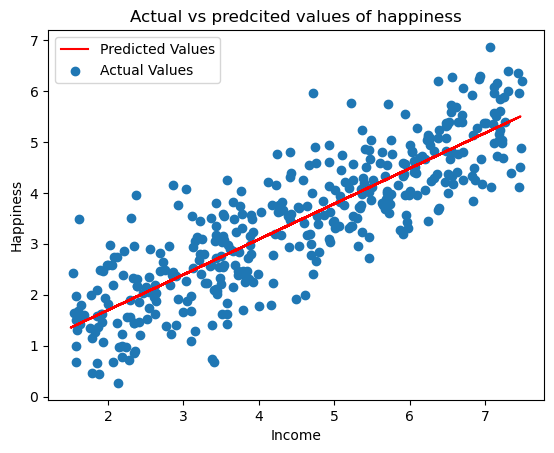

In [31]:
plt.plot(x_test, y_pred, color="red", label="Predicted Values")
plt.scatter(x_train, y_train, label="Actual Values")

plt.title("Actual vs predcited values of happiness")
plt.xlabel("Income")
plt.ylabel("Happiness")
plt.legend()